## Mount & Path

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
 
# path_file  = '/content/drive/MyDrive/tesisugm/' #google colab
path_file = ''  # local

KOMPOSISI  = "joint_search"

## Load Features Module

In [2]:
import importlib.util, sys
 
# MODULE_PATH = "/content/drive/MyDrive/tesisugm/no-leakage/features.py"
MODULE_PATH = "features.py"

spec    = importlib.util.spec_from_file_location("features", MODULE_PATH)
features = importlib.util.module_from_spec(spec)
sys.modules["features"] = features
spec.loader.exec_module(features)
print("Features file   :", features.__file__)
print("Features version:", features.FEATURES_VERSION)

Features file   : features.py
Features version: Shami Extractor


## Imports

In [3]:
import os, gc, warnings, hashlib, itertools, time, math
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
import joblib
from collections import Counter
from itertools import product as iproduct
from scipy.sparse import issparse, csr_matrix, vstack, diags
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder, normalize
from sklearn.metrics          import f1_score
from sklearn.cluster          import MiniBatchKMeans, DBSCAN
from sklearn.neighbors        import NearestNeighbors
from sklearn.utils            import check_random_state
from imblearn.over_sampling   import SMOTE
from features import ShamiFeatureExtractor, clean_noise, clean_char


# Set environment variable
os.environ['PYTHONWARNINGS'] = 'ignore'

# Suppress all warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# Specific sklearn warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', module='sklearn.utils.validation')

# Your existing code
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', message='X does not have valid feature names')
 
warnings.filterwarnings("ignore")
print("Libraries loaded.")
 

Libraries loaded.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# ── Global Theme ────────────────────────────────────────────
PALETTE   = ["#2D4A7A", "#4A90C4", "#6DB8A8", "#C4956A"]  # Jordan, Lebanon, Palestine, Syria
BG_COLOR  = "#F8F9FB"
CARD_COLOR= "#FFFFFF"
TEXT_DARK = "#1A2640"
TEXT_MID  = "#4A5568"
TEXT_LIGHT= "#8A97AA"
GRID_COLOR= "#E8ECF1"

def set_global_style():
    plt.rcParams.update({
        "figure.facecolor"  : BG_COLOR,
        "axes.facecolor"    : CARD_COLOR,
        "axes.edgecolor"    : GRID_COLOR,
        "axes.linewidth"    : 0.8,
        "axes.grid"         : True,
        "grid.color"        : GRID_COLOR,
        "grid.linewidth"    : 0.6,
        "grid.alpha"        : 0.8,
        "text.color"        : TEXT_DARK,
        "axes.labelcolor"   : TEXT_MID,
        "xtick.color"       : TEXT_MID,
        "ytick.color"       : TEXT_MID,
        "xtick.labelsize"   : 10,
        "ytick.labelsize"   : 10,
        "axes.labelsize"    : 11,
        "axes.titlesize"    : 13,
        "axes.titleweight"  : "bold",
        "axes.titlepad"     : 12,
        "font.family"       : "sans-serif",
        # "font.sans-serif"   : ["Helvetica Neue", "Arial", "DejaVu Sans"],
        "axes.spines.top"   : False,
        "axes.spines.right" : False,
    })
set_global_style()

print("✅ Global style set!")

✅ Global style set!


## Inisiasi Path

In [5]:
# ROOT
BASE_DIR = os.path.join(path_file, "artifacts")

# GLOBAL SAVE
SAVE_DIR = os.path.join(BASE_DIR, "output")

# PER KOMPOSISI
KOMPOSISI_DIR = os.path.join(BASE_DIR, KOMPOSISI)

# SUB DIR
MODEL_DIR = os.path.join(KOMPOSISI_DIR, "model")
IMAGE_DIR = os.path.join(KOMPOSISI_DIR, "image")
DOCS_DIR  = os.path.join(KOMPOSISI_DIR, "docs")

# CREATE ALL
for d in [SAVE_DIR, KOMPOSISI_DIR, MODEL_DIR, IMAGE_DIR, DOCS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Semua path berhasil diinisialisasi!")

✅ Semua path berhasil diinisialisasi!


In [6]:
def save_and_show(name):
    path = os.path.join(IMAGE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

def global_image(name):
    path = os.path.join(SAVE_DIR, f"{name}.png")
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f"🖼️ Saved: {path}")
    plt.show()
    plt.close()

## Data Preparation

In [7]:
df = pd.read_csv(f'../{path_file}dataset/shami_preprocessed_dataset_raw.csv')
df = (
    df.dropna(subset=["text", "label"])
      .rename(columns={"label": "country"})
)
df["clean_word"] = df["text"].apply(clean_noise)
df["clean_char"] = df["text"].apply(clean_char)
 
try:    display(df.head())
except: print(df.head())
display(df['country'].value_counts(normalize=True))

,text,country,clean_word,clean_char
0,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,Palestine,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...,هه اصلا حاليا في وفد قطري موجود بغزه واللعبه ه...
1,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,Palestine,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...,عادي طعميها لانها ما راح تكتفي من صدرك صار بده...
2,اعملي اللي عليكي لوجه الله,Palestine,اعملي اللي عليكي لوجه الله,اعملي اللي عليكي لوجه الله
3,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,Palestine,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها,حكت شفتها اكتر من مره بلبس قصير واكيد زوجي شافها
4,و هيا واياه بتزوجو هه,Palestine,و هيا واياه بتزوجو هه,و هيا واياه بتزوجو هه


country
Syria        0.569973
Lebanon      0.163464
Palestine    0.160641
Jordan       0.105922
Name: proportion, dtype: float64

### Class distribution plot 

🖼️ Saved: artifacts/output/class_distribution.png


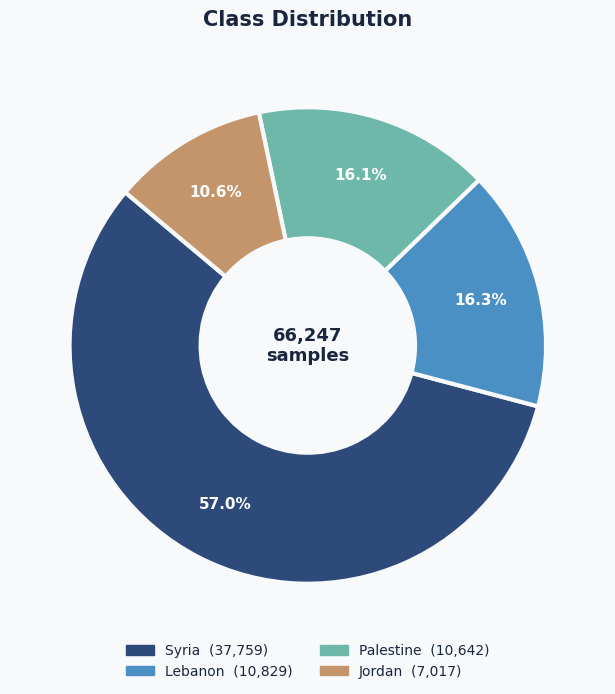

In [8]:
class_dist = df['country'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG_COLOR)
wedges, texts, autotexts = ax.pie(
    class_dist,
    labels=None,
    autopct='%1.1f%%',
    startangle=140,
    colors=PALETTE,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=BG_COLOR, linewidth=3),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

# Centre label
ax.text(0, 0, f"{class_dist.sum():,}\nsamples",
        ha='center', va='center', fontsize=13,
        fontweight='bold', color=TEXT_DARK)

# Legend
legend_labels = [f"{c}  ({v:,})" for c, v in class_dist.items()]
patches = [mpatches.Patch(color=PALETTE[i], label=legend_labels[i])
           for i in range(len(class_dist))]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.08),
          ncol=2, frameon=False, fontsize=10)

ax.set_title("Class Distribution", fontsize=15, fontweight='bold',
             color=TEXT_DARK, pad=16)
fig.tight_layout()
global_image("class_distribution")

### Split

In [9]:
X = df[["text", "clean_word", "clean_char"]]
y = df["country"]
 
le          = LabelEncoder()
y_encoded   = le.fit_transform(y)
label_names = le.classes_
label_mapping   = {label: idx  for idx, label in enumerate(label_names)}
class_name_map  = {i: name     for i, name   in enumerate(label_names)}
print("Label mapping:", label_mapping)
 
from collections import Counter
 
def print_class_distribution(y_data, title):
    counter = Counter(y_data)
    print(f"\n=== {title} ===")
    total = len(y_data)
    for cls_id in sorted(counter.keys()):
        cls_name = class_name_map[cls_id]
        count    = counter[cls_id]
        print(f"{cls_id} ({cls_name}) : {count} ({count/total*100:.2f}%)")
    print("Total :", total)
 
print_class_distribution(y_encoded, "BEFORE SPLIT")
 
X_train_full, X_test,  y_train_full, y_test  = train_test_split(
    X, y_encoded, test_size=0.25, stratify=y_encoded, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20,
    stratify=y_train_full, random_state=42)
 
print_class_distribution(y_train, "TRAIN SET")
print_class_distribution(y_val,   "VALIDATION SET")
print_class_distribution(y_test,  "TEST SET")

Label mapping: {'Jordan': 0, 'Lebanon': 1, 'Palestine': 2, 'Syria': 3}

=== BEFORE SPLIT ===
0 (Jordan) : 7017 (10.59%)
1 (Lebanon) : 10829 (16.35%)
2 (Palestine) : 10642 (16.06%)
3 (Syria) : 37759 (57.00%)
Total : 66247

=== TRAIN SET ===
0 (Jordan) : 4210 (10.59%)
1 (Lebanon) : 6498 (16.35%)
2 (Palestine) : 6385 (16.06%)
3 (Syria) : 22655 (57.00%)
Total : 39748

=== VALIDATION SET ===
0 (Jordan) : 1053 (10.60%)
1 (Lebanon) : 1624 (16.34%)
2 (Palestine) : 1596 (16.06%)
3 (Syria) : 5664 (57.00%)
Total : 9937

=== TEST SET ===
0 (Jordan) : 1754 (10.59%)
1 (Lebanon) : 2707 (16.34%)
2 (Palestine) : 2661 (16.07%)
3 (Syria) : 9440 (57.00%)
Total : 16562


## Feature Extraction

In [10]:
CHI2_PCT             = 0.015
MI_PCT23             = 0.010
MI_PCT45             = 0.015
USE_OOF_INTERACTION = True   # flag diteruskan ke ShamiFeatureExtractor
 
split_hash = hashlib.md5(pd.util.hash_pandas_object(X_train["text"]).values).hexdigest()[:10]
base_signature = f"{features.FEATURES_VERSION}_{split_hash}"
base_cache_dir = os.path.join(path_file, "cache", base_signature)
os.makedirs(base_cache_dir, exist_ok=True)
 
feat_cache_key = (
    f"chi2_{CHI2_PCT}_mi23_{MI_PCT23}_mi45_{MI_PCT45}"
    f"_oof_inter_{int(USE_OOF_INTERACTION)}"
)
data_hash = hashlib.md5(df["text"].str.cat().encode()).hexdigest()[:8]

feat_cache_dir = os.path.join(
    base_cache_dir,
    feat_cache_key,
    data_hash
)

os.makedirs(feat_cache_dir, exist_ok=True)
print("Base signature :", base_signature)
print("Feat cache dir :", feat_cache_dir)
 
feat_path = os.path.join(base_cache_dir, "feature_extractor.pkl")
if os.path.exists(feat_path):
    print("✅ Loading base extractor...")
    feat = joblib.load(feat_path)
else:
    print("⚙️ Building base extractor (MI fit bisa makan waktu 2-5 menit)...")
    feat = ShamiFeatureExtractor(
        chi2_pct=CHI2_PCT,
        mi_pct23=MI_PCT23,
        mi_pct45=MI_PCT45,
        use_oof_lr=True,
        use_oof_interaction=USE_OOF_INTERACTION, 
    )
    feat.fit(X_train, y_train) 
    joblib.dump(feat, feat_path)
print("Base extractor ready.")

Base signature : Shami Extractor_0890ac2785
Feat cache dir : cache/Shami Extractor_0890ac2785/chi2_0.015_mi23_0.01_mi45_0.015_oof_inter_1/6ace3dc3
✅ Loading base extractor...
Base extractor ready.


### Update k

In [11]:
feat.update_chi2_pct(CHI2_PCT)
feat.update_mi_pct(new_pct23=MI_PCT23, new_pct45=MI_PCT45)
 
# ---- Info dimensi ----
print("\nMI info     :", feat.mi_info)
print("Block sizes :", feat.block_sizes)

[update] chi2_pct=1.50% -> chi2_k=2,420
[update] mi_pct23=1.00% -> mi_k23=500
[update] mi_pct45=1.50% -> mi_k45=2,650

MI info     : {'chi2_pct': 0.015, 'chi2_k_eff': 2420, 'mi_pct23': 0.01, 'mi_k23_eff': 500, 'char23_vocab': 10964, 'char23_selected': 500, 'mi_pct45': 0.015, 'mi_k45_eff': 2650, 'char45_vocab': 176676, 'char45_selected': 2650}
Block sizes : {'lexical': 2420, 'char_mi23': 500, 'char_mi45': 2650, 'doc_stats': 7, 'stopword': 2, 'morph': 26, 'morph_inter': 8, 'colloc_dom': 1, 'nbsvm': 4, 'oof_lr': 8, 'oof_svm': 8, 'oof_interactions': 10}


### Lexical Info

In [12]:
dims = {
    "tfidf_wL_uni": len(feat.tfidf_wL_uni.vocabulary_),
    "tfidf_wL_23" : len(feat.tfidf_wL_23.vocabulary_),
    "tfidf_wA_uni": len(feat.tfidf_wA_uni.vocabulary_),
    "tfidf_wA_23" : len(feat.tfidf_wA_23.vocabulary_),
    "tfidf_char"  : len(feat.tfidf_char.vocabulary_),
    "bm25_word"   : len(feat.bm25w.cv.vocabulary_),
    "bm25_char"   : len(feat.bm25c.cv.vocabulary_),
}
print("\n==============================")
print("LEXICAL FEATURES BEFORE CHI2")
print("==============================")
for k, v in dims.items():
    print(f"{k:15s}: {v:,}")
print(f"\nLEXICAL total  : {sum(dims.values()):,}")
 
ranges = {}
start  = 0
for name, size in dims.items():
    ranges[name] = (start, start + size)
    start += size
counts = {k: 0 for k in dims}
for c in feat._chi2_cols:
    for name, (s, e) in ranges.items():
        if s <= c < e:
            counts[name] += 1
            break
print("\n==============================")
print("LEXICAL FEATURES AFTER CHI2")
print("==============================")
for k, v in counts.items():
    print(f"{k:15s}: {v:,}")
print(f"\nTotal chi2 selected: {len(feat._chi2_cols):,}")


LEXICAL FEATURES BEFORE CHI2
tfidf_wL_uni   : 19,234
tfidf_wL_23    : 19,234
tfidf_wA_uni   : 19,226
tfidf_wA_23    : 19,226
tfidf_char     : 34,631
bm25_word      : 40,562
bm25_char      : 9,272

LEXICAL total  : 161,385

LEXICAL FEATURES AFTER CHI2
tfidf_wL_uni   : 115
tfidf_wL_23    : 115
tfidf_wA_uni   : 115
tfidf_wA_23    : 115
tfidf_char     : 843
bm25_word      : 316
bm25_char      : 801

Total chi2 selected: 2,420


In [13]:
print("\n==============================")
print("CHAR FEATURES BEFORE MI")
print("==============================")

print(f"char_2_3 vocab: {feat._X_char23_tr.shape[1]:,}")
print(f"char_4_5 vocab: {feat._X_char45_tr.shape[1]:,}")
print(f"Total char    : {feat._X_char23_tr.shape[1] + feat._X_char45_tr.shape[1]:,}")

print("\n==============================")
print("CHAR FEATURES AFTER MI")
print("==============================")

print(f"char_mi23: {feat._mi_sel23.n_selected:,}")
print(f"char_mi45: {feat._mi_sel45.n_selected:,}")
print(f"Total MI  : {feat._mi_sel23.n_selected + feat._mi_sel45.n_selected:,}")


CHAR FEATURES BEFORE MI
char_2_3 vocab: 10,964
char_4_5 vocab: 176,676
Total char    : 187,640

CHAR FEATURES AFTER MI
char_mi23: 500
char_mi45: 2,650
Total MI  : 3,150


### Build / Load Feature Matrices

In [14]:
xtr_path  = os.path.join(feat_cache_dir, "Xtr_feat.pkl")
xval_path = os.path.join(feat_cache_dir, "Xval_feat.pkl")
xte_path  = os.path.join(feat_cache_dir, "Xte_feat.pkl")
ytr_path  = os.path.join(feat_cache_dir, "y_train.pkl")
yval_path = os.path.join(feat_cache_dir, "y_val.pkl")
yte_path  = os.path.join(feat_cache_dir, "y_test.pkl")
 
if all(os.path.exists(p) for p in [xtr_path, xval_path, xte_path,
                                    ytr_path, yval_path, yte_path]):
    print("✅ Loading feature matrices from cache...")
    Xtr_feat  = joblib.load(xtr_path)
    Xval_feat = joblib.load(xval_path)
    Xte_feat  = joblib.load(xte_path)
    y_train   = joblib.load(ytr_path)
    y_val     = joblib.load(yval_path)
    y_test    = joblib.load(yte_path)
else:
    print("⚙️ Building feature matrices...")
    # feat.transform() output:
    # [lexical_chi2 | char_mi23 | char_mi45 | structural | oof_lr | oof_svm | oof_interactions]
    Xtr_feat  = feat.transform(X_train, is_train=True)   
    Xval_feat = feat.transform(X_val,   is_train=False)  
    Xte_feat  = feat.transform(X_test,  is_train=False)  
    gc.collect()
    joblib.dump(Xtr_feat,  xtr_path)
    joblib.dump(Xval_feat, xval_path)
    joblib.dump(Xte_feat,  xte_path)
    joblib.dump(y_train,   ytr_path)
    joblib.dump(y_val,     yval_path)
    joblib.dump(y_test,    yte_path)
 
print(f"Train shape : {Xtr_feat.shape}")
print(f"Val shape   : {Xval_feat.shape}")
print(f"Test shape  : {Xte_feat.shape}")

✅ Loading feature matrices from cache...
Train shape : (39748, 5644)
Val shape   : (9937, 5644)
Test shape  : (16562, 5644)


### Block Ablation Utilities

In [15]:
def build_block_slices(block_sizes):
    slices = {}
    start  = 0
    for name, size in block_sizes.items():
        slices[name] = (start, start + size)
        start += size
    return slices
 
def drop_blocks(X, block_slices, drop_list):
    keep_cols = []
    for name, (s, e) in block_slices.items():
        if name not in drop_list:
            keep_cols.extend(range(s, e))
        else:
            print(f"  Dropping block: {name}  size={e - s:,}")
    keep_cols = np.array(keep_cols)
    return X[:, keep_cols], keep_cols
 
block_slices = build_block_slices(feat.block_sizes)
print("\nBlock slices:")
for k, (s, e) in block_slices.items():
    print(f"  {k:20s}: cols {s:5d}–{e:5d}  ({e - s:,})")


Block slices:
  lexical             : cols     0– 2420  (2,420)
  char_mi23           : cols  2420– 2920  (500)
  char_mi45           : cols  2920– 5570  (2,650)
  doc_stats           : cols  5570– 5577  (7)
  stopword            : cols  5577– 5579  (2)
  morph               : cols  5579– 5605  (26)
  morph_inter         : cols  5605– 5613  (8)
  colloc_dom          : cols  5613– 5614  (1)
  nbsvm               : cols  5614– 5618  (4)
  oof_lr              : cols  5618– 5626  (8)
  oof_svm             : cols  5626– 5634  (8)
  oof_interactions    : cols  5634– 5644  (10)


In [16]:
# ---- Ubah drop_list untuk ablasi ----
drop_list = []
if drop_list:
    print("\nDropping blocks:", drop_list)
    Xtr_sel,  _         = drop_blocks(Xtr_feat,  block_slices, drop_list)
    Xval_sel, _         = drop_blocks(Xval_feat, block_slices, drop_list)
    Xte_sel,  kept_cols = drop_blocks(Xte_feat,  block_slices, drop_list)
else:
    print("\nNo block dropped.")
    Xtr_sel   = Xtr_feat
    Xval_sel  = Xval_feat
    Xte_sel   = Xte_feat
    kept_cols = np.arange(Xtr_feat.shape[1])


No block dropped.


In [17]:
# ============================================================
## SVD (opsional, default OFF)
# ============================================================
USE_SVD = False
if USE_SVD:
    from sklearn.decomposition import TruncatedSVD
    print("\nApplying SVD compression...")
    svd      = TruncatedSVD(n_components=200, random_state=42)
    Xtr_sel  = svd.fit_transform(Xtr_sel)
    Xval_sel = svd.transform(Xval_sel)
    Xte_sel  = svd.transform(Xte_sel)
    print(f"Train: {Xtr_sel.shape}")
else:
    print("Skipping SVD (recommended for LightGBM)")
    print(f"Train: {Xtr_sel.shape}")

Skipping SVD (recommended for LightGBM)
Train: (39748, 5644)


## Joint Search

### Load Model Best Params

In [18]:
# Load best params kedua model
best_params_lgb = joblib.load(
    os.path.join(SAVE_DIR, "lightgbm_original_best_params.pkl"))
best_params_xgb = joblib.load(
    os.path.join(SAVE_DIR, "xgboost_original_best_params.pkl"))

print(f"\n✅ LGB best params: {best_params_lgb}")
print(f"✅ XGB best params: {best_params_xgb}")


✅ LGB best params: {'num_leaves': 25, 'colsample_bytree': 0.4, 'reg_alpha': 1.0, 'reg_lambda': 1.0, 'min_child_samples': 50}
✅ XGB best params: {'max_depth': 8, 'colsample_bytree': 0.3, 'reg_alpha': 1.5, 'reg_lambda': 1.5, 'min_child_weight': 30}


In [19]:
# Fixed config — sama persis dengan notebook masing-masing
LGB_FIXED = dict(
    objective="multiclass", num_class=len(label_names),
    n_estimators=10000, learning_rate=0.1,
    max_depth=7, min_child_weight=1e-3,
    subsample=0.75, subsample_freq=1,
    random_state=42, n_jobs=-1, force_col_wise=True, verbose=-1,
)

XGB_FIXED = dict(
    objective="multi:softprob", num_class=len(label_names), learning_rate=0.1,
    subsample=0.75, tree_method="hist", device="cpu", grow_policy="lossguide",
    multi_strategy="one_output_per_tree", random_state=42, max_bin=64, verbosity=0
)

# Info distribusi
class_counts = Counter(y_train)
maj_class    = max(class_counts, key=class_counts.get)
maj_count    = class_counts[maj_class]
min_count    = min(class_counts.values())
cls_indices  = sorted([c for c in class_counts if c != maj_class])

print(f"\nClass distribution:")
for cls, cnt in sorted(class_counts.items()):
    print(f"  {label_names[cls]:12s}: {cnt:,}  "
          f"({cnt/maj_count*100:.1f}% of majority)")


Class distribution:
  Jordan      : 4,210  (18.6% of majority)
  Lebanon     : 6,498  (28.7% of majority)
  Palestine   : 6,385  (28.2% of majority)
  Syria       : 22,655  (100.0% of majority)


### Helper Eval Joint

In [ ]:
def eval_joint(Xtr_os, ytr_os, label=""):
    """Train LGB dan XGB, return dict hasil."""

    # LightGBM (Tetap sesuai aslinya)
    m_lgb = lgb.LGBMClassifier(**LGB_FIXED, **best_params_lgb)
    m_lgb.fit(
        Xtr_os, ytr_os,
        eval_set=[(Xval_sel, y_val)],
        eval_metric="multi_logloss",
        callbacks=[
            lgb.early_stopping(15, min_delta=1e-4, verbose=False),
            lgb.log_evaluation(-1),
        ]
    )
    f1_lgb_val  = f1_score(y_val,  m_lgb.predict(Xval_sel,
                           num_iteration=m_lgb.best_iteration_), average="macro")

    # XGBoost (Dioptimasi tanpa ubah nama variabel luar)
    dtrain_joint = xgb.DMatrix(Xtr_os, label=ytr_os, missing=0.0)
    dval_joint   = xgb.DMatrix(Xval_sel, label=y_val, missing=0.0)

    xgb_params = {**XGB_FIXED, **best_params_xgb}

    bst_joint = xgb.train(
        params=xgb_params,
        dtrain=dtrain_joint,
        num_boost_round=10000,
        evals=[(dval_joint, "validation")],
        early_stopping_rounds=15,
        verbose_eval=False
    )

    # Bungkus ke m_xgb agar tetap bisa pakai m_xgb.predict di bawah
    m_xgb = xgb.XGBClassifier(**{**XGB_FIXED, **best_params_xgb})
    m_xgb._Booster = bst_joint
    m_xgb._n_classes = len(label_names)
    m_xgb._classes = np.arange(len(label_names))
    if not hasattr(m_xgb, 'n_classes_'): m_xgb.n_classes_ = len(label_names)

    # f1_xgb_val tetap menggunakan m_xgb sesuai kodemu
    f1_xgb_val  = f1_score(y_val,  m_xgb.predict(Xval_sel, iteration_range=(0, bst_joint.best_iteration + 1)), average="macro")

    # Hitung Joint
    f1_joint = 2 * (f1_lgb_val * f1_xgb_val) / (f1_lgb_val + f1_xgb_val)

    return {
        "F1_LGB_Val"  : round(f1_lgb_val,  4),
        "F1_XGB_Val"  : round(f1_xgb_val,  4),
        "F1_Joint"    : round(f1_joint,    4)
    }


### SMOTE Joint Search

In [ ]:
FILL_OPTIONS = [0.0, 0.2, 0.3, 0.5, 0.8, 1.0]
K_FIXED      = 5   # fixed, tidak dituning

combinations = list(iproduct(*[FILL_OPTIONS] * len(cls_indices)))
print(f"Fill options    : {FILL_OPTIONS}")
print(f"k_neighbors     : {K_FIXED}  (fixed)")
print(f"Minority classes: {[label_names[c] for c in cls_indices]}")
print(f"Total kombinasi : {len(combinations)}")

k_safe = max(1, min(K_FIXED, min_count - 1))

smote_results = []

print("\n" + "="*70)
print(" TUNING SMOTE (sampling_strategy)")
print("="*70)

t_smote_start = time.time()
for combo in combinations:
    t0 = time.time()

    # Bangun sampling_strategy
    sampling_strategy = {}
    for cls_idx, fill in zip(cls_indices, combo):
        if fill == 0.0:
            continue
        cnt    = class_counts[cls_idx]
        target = int(cnt + (maj_count - cnt) * fill)
        if target > cnt:
            sampling_strategy[cls_idx] = target

    combo_label = " | ".join([f"{label_names[c]}={f}"
                               for c, f in zip(cls_indices, combo)])

    # Apply SMOTE
    if not sampling_strategy:
        Xtr_os, ytr_os = Xtr_sel, y_train
    else:
        smote = SMOTE(
            sampling_strategy=sampling_strategy,
            k_neighbors=k_safe,
            random_state=42,
        )
        try:
            Xtr_os, ytr_os = smote.fit_resample(Xtr_sel, y_train)
        except Exception as e:
            print(f"  ❌ [{combo_label}]: {e}")
            continue

    # Joint eval
    res     = eval_joint(Xtr_os, ytr_os)
    elapsed = round(time.time() - t0, 1)

    print(f"  [{combo_label}] "
          f"n={Xtr_os.shape[0]:,} | "
          f"LGB={res['F1_LGB_Val']:.4f} "
          f"XGB={res['F1_XGB_Val']:.4f} "
          f"Joint={res['F1_Joint']:.4f} | {elapsed}s")

    row = {
        "combo"         : combo_label,
        "k_neighbors"   : k_safe,
        "n_train_after" : Xtr_os.shape[0],
        "elapsed_sec"   : elapsed,
        **res,
    }
    for cls_idx, fill in zip(cls_indices, combo):
        row[f"fill_{label_names[cls_idx]}"] = fill
    smote_results.append(row)

print(f"\n⏱ Total SMOTE search: {round(time.time() - t_smote_start, 1)}s")
df_smote = (pd.DataFrame(smote_results)
              .sort_values("F1_Joint", ascending=False)
              .reset_index(drop=True))

print("\n🏆 Top 5 SMOTE:")
print(df_smote.head(5).to_string(index=False))
df_smote.to_csv(
    os.path.join(DOCS_DIR, "smote_joint_search.csv"), index=False)

# Best
best_smote          = df_smote.iloc[0]
BEST_SAMPLING_STRATEGY = {}
for cls_idx in cls_indices:
    fill   = float(best_smote[f"fill_{label_names[cls_idx]}"])
    cnt    = class_counts[cls_idx]
    target = int(cnt + (maj_count - cnt) * fill)
    if fill > 0.0 and target > cnt:
        BEST_SAMPLING_STRATEGY[cls_idx] = target

print(f"\n🏆 Best SMOTE combo  : {best_smote['combo']}")
print(f"   Best strategy     : {BEST_SAMPLING_STRATEGY}")
print(f"   F1 LGB Val        : {best_smote['F1_LGB_Val']:.4f}")
print(f"   F1 XGB Val        : {best_smote['F1_XGB_Val']:.4f}")
print(f"   F1 Joint          : {best_smote['F1_Joint']:.4f}")

# Simpan
joblib.dump(BEST_SAMPLING_STRATEGY,
    os.path.join(SAVE_DIR, "best_sampling_strategy.pkl"))
joblib.dump(K_FIXED,
    os.path.join(SAVE_DIR, "best_k_neighbors.pkl"))
print(f"\n✅ best_sampling_strategy.pkl saved")
print(f"✅ best_k_neighbors.pkl saved")

Fill options    : [0.0, 0.2, 0.3, 0.5, 0.8, 1.0]
k_neighbors     : 5  (fixed)
Minority classes: ['Jordan', 'Lebanon', 'Palestine']
Total kombinasi : 216

 TUNING SMOTE (sampling_strategy)
  [Jordan=0.0 | Lebanon=0.0 | Palestine=0.0] n=39,748 | LGB=0.8486 XGB=0.8517 Joint=0.8502 | 202.2s
  [Jordan=0.0 | Lebanon=0.0 | Palestine=0.2] n=43,002 | LGB=0.8489 XGB=0.8523 Joint=0.8506 | 239.8s
  [Jordan=0.0 | Lebanon=0.0 | Palestine=0.3] n=44,629 | LGB=0.8500 XGB=0.8499 Joint=0.8500 | 279.4s
  [Jordan=0.0 | Lebanon=0.0 | Palestine=0.5] n=47,883 | LGB=0.8472 XGB=0.8506 Joint=0.8489 | 287.4s
  [Jordan=0.0 | Lebanon=0.0 | Palestine=0.8] n=52,764 | LGB=0.8479 XGB=0.8484 Joint=0.8481 | 319.8s
  [Jordan=0.0 | Lebanon=0.0 | Palestine=1.0] n=56,018 | LGB=0.8493 XGB=0.8478 Joint=0.8485 | 296.0s
  [Jordan=0.0 | Lebanon=0.2 | Palestine=0.0] n=42,979 | LGB=0.8465 XGB=0.8475 Joint=0.8470 | 247.8s
  [Jordan=0.0 | Lebanon=0.2 | Palestine=0.2] n=46,233 | LGB=0.8501 XGB=0.8503 Joint=0.8502 | 295.3s
  [Jordan=0.

### ASTRA-SMOTE Joint Tuning

In [22]:
import time
import pandas as pd
import numpy as np
import os
import joblib

print(f"sampling_strategy (fixed): {BEST_SAMPLING_STRATEGY}")
print(f"k_neighbors       (fixed): {K_FIXED}")

# Pastikan sudah import class dari module yang baru
from hybrid_oversampling import ASTRA_SMOTE

N_CLUSTERS   = max(10, int(np.sqrt(min_count)))
k_safe_astra = max(1, min(K_FIXED, min_count - 1))

TUNE_GRID_ASTRA = {
    "n_clusters"    : [N_CLUSTERS // 2, N_CLUSTERS, N_CLUSTERS * 2],
    "safe_threshold": [0.1, 0.3, 0.5],
    "alpha_mode"    : ['adaptive', 'full']
}

astra_results = []
total_kombinasi = (len(TUNE_GRID_ASTRA['n_clusters']) * len(TUNE_GRID_ASTRA['safe_threshold']) * len(TUNE_GRID_ASTRA['alpha_mode']))

print(f"\nn_clusters options : {TUNE_GRID_ASTRA['n_clusters']}")
print(f"safe_threshold opts: {TUNE_GRID_ASTRA['safe_threshold']}")
print(f"alpha_mode opts    : {TUNE_GRID_ASTRA['alpha_mode']}")
print(f"Total kombinasi    : {total_kombinasi}")

print("\n" + "="*80)
print(" TUNING ASTRA-SMOTE (n_clusters × safe_threshold × alpha_mode)")
print("="*80)

t_astra_start = time.time()
for nc in TUNE_GRID_ASTRA["n_clusters"]:
    for st in TUNE_GRID_ASTRA["safe_threshold"]:
        for am in TUNE_GRID_ASTRA["alpha_mode"]: # ← Loop ke-3 untuk alpha_mode
            t0 = time.time()

            # Memanggil class ASTRA_SMOTE yang baru
            astra = ASTRA_SMOTE(
                n_clusters        = nc,
                k_neighbors       = k_safe_astra,
                safe_threshold    = st,
                alpha_mode        = am,               # ← Masukkan parameter tuning
                sampling_strategy = BEST_SAMPLING_STRATEGY,
                batch_size        = 5000,
                max_iters         = 20,
                verbose           = 0,                # Diset 0 biar terminal nggak banjir log
                random_state      = 42,
            )
            
            try:
                Xtr_os, ytr_os = astra.fit_resample(
                    Xtr_sel, y_train, label_names=label_names)
            except Exception as e:
                print(f"  ❌ nc={nc} st={st} am={am}: {e}")
                continue

            total_syn = astra.metadata_["summary"]["total_synth"]
            res       = eval_joint(Xtr_os, ytr_os) # Asumsi fungsi eval_joint kamu udah siap
            elapsed   = round(time.time() - t0, 1)

            # Print rapi di terminal
            print(f"  nc={nc:4d} | st={st:.1f} | am={am:8s} | "
                  f"syn={total_syn:6,} | n={Xtr_os.shape[0]:,} | "
                  f"LGB={res['F1_LGB_Val']:.4f} "
                  f"XGB={res['F1_XGB_Val']:.4f} "
                  f"Joint={res['F1_Joint']:.4f} | {elapsed}s")

            row = {
                "n_clusters"    : nc,
                "safe_threshold": st,
                "alpha_mode"    : am,                 # ← Simpan ke hasil CSV
                "k_neighbors"   : k_safe_astra,
                "total_synth"   : total_syn,
                "n_train_after" : Xtr_os.shape[0],
                "elapsed_sec"   : elapsed,
                **res,
            }
            astra_results.append(row)

print(f"\n⏱ Total ASTRA tuning: {round(time.time() - t_astra_start, 1)}s")

# Olah hasil ke DataFrame
df_astra = (pd.DataFrame(astra_results)
            .sort_values("F1_Joint", ascending=False)
            .reset_index(drop=True))

print("\n🏆 ASTRA-SMOTE Tuning Results:")
print(df_astra.head(10).to_string(index=False))

# Simpan ke CSV
df_astra.to_csv(
    os.path.join(DOCS_DIR, "astra_smote_joint_tuning.csv"), index=False)

# Ambil config terbaik (Baris pertama setelah di-sort)
best_astra = df_astra.iloc[0]
BEST_ASTRA_CONFIG = {
    "n_clusters"        : int(best_astra["n_clusters"]),
    "safe_threshold"    : float(best_astra["safe_threshold"]),
    "alpha_mode"        : best_astra["alpha_mode"],
    "k_neighbors"       : k_safe_astra,
    "sampling_strategy" : BEST_SAMPLING_STRATEGY,
}

print(f"🏆 BEST ASTRA-SMOTE CONFIG:")
print(f"   n_clusters     : {BEST_ASTRA_CONFIG['n_clusters']}")
print(f"   safe_threshold : {BEST_ASTRA_CONFIG['safe_threshold']}")
print(f"   alpha_mode     : {BEST_ASTRA_CONFIG['alpha_mode']}")
print("-" * 30)
print(f"   F1 LGB Val     : {best_astra['F1_LGB_Val']:.4f}")
print(f"   F1 XGB Val     : {best_astra['F1_XGB_Val']:.4f}")
print(f"   F1 Joint       : {best_astra['F1_Joint']:.4f}")

# Save config terbaik ke pickle
joblib.dump(BEST_ASTRA_CONFIG,
    os.path.join(SAVE_DIR, "best_astra_smote_config.pkl"))
print(f"\n✅ best_astra_smote_config.pkl saved successfully di folder {SAVE_DIR}!")

sampling_strategy (fixed): {np.int64(0): 7899, np.int64(1): 19423, np.int64(2): 19401}
k_neighbors       (fixed): 5

n_clusters options : [32, 64, 128]
safe_threshold opts: [0.1, 0.3, 0.5]
alpha_mode opts    : ['adaptive', 'full']
Total kombinasi    : 18

 TUNING ASTRA-SMOTE (n_clusters × safe_threshold × alpha_mode)
  nc=  32 | st=0.1 | am=adaptive | syn=26,291 | n=66,039 | LGB=0.8459 XGB=0.8524 Joint=0.8491 | 335.7s
  nc=  32 | st=0.1 | am=full     | syn=29,630 | n=69,378 | LGB=0.8489 XGB=0.8505 Joint=0.8497 | 369.1s
  nc=  32 | st=0.3 | am=adaptive | syn=14,151 | n=53,899 | LGB=0.8485 XGB=0.8485 Joint=0.8485 | 291.2s
  nc=  32 | st=0.3 | am=full     | syn=29,630 | n=69,378 | LGB=0.8500 XGB=0.8493 Joint=0.8496 | 389.9s
  nc=  32 | st=0.5 | am=adaptive | syn= 2,028 | n=41,776 | LGB=0.8480 XGB=0.8457 Joint=0.8469 | 253.6s
  nc=  32 | st=0.5 | am=full     | syn=29,630 | n=69,378 | LGB=0.8447 XGB=0.8487 Joint=0.8467 | 388.9s
  nc=  64 | st=0.1 | am=adaptive | syn=26,083 | n=65,831 | LGB=

### SMOTE-RADIANT Joint Tuning

In [23]:
import time
import pandas as pd
import os
import joblib
from itertools import product as iproduct

print(f"sampling_strategy (fixed): {BEST_SAMPLING_STRATEGY}")
print(f"k_neighbors       (fixed): {K_FIXED}")

# Pastikan sudah import class dari module yang baru
from hybrid_oversampling import SMOTE_RADIANT

TUNE_GRID_RADIANT = {
    "eps"             : ['auto', 0.2, 0.4],
    "min_samples"     : ['auto', 3, 5],
    "clean_only_synth": [True, False],
    "strict_target"   : [True, False]
}

radiant_combos = list(iproduct(
    TUNE_GRID_RADIANT["eps"],
    TUNE_GRID_RADIANT["min_samples"],
    TUNE_GRID_RADIANT["clean_only_synth"],
    TUNE_GRID_RADIANT["strict_target"],
))

radiant_results = []
print(f"\nTotal kombinasi SMOTE-RADIANT: {len(radiant_combos)}")
print("\n" + "="*80)
print(" TUNING SMOTE-RADIANT (eps × min_s × clean_synth × strict_target)")
print("="*80)

t_radiant_start = time.time()
for eps_v, min_s_v, cos_v, st_v in radiant_combos:
    t0 = time.time()

    # Memanggil class SMOTE_RADIANT yang baru
    radiant = SMOTE_RADIANT(
        sampling_strategy = BEST_SAMPLING_STRATEGY,
        k_neighbors       = K_FIXED,
        eps               = eps_v,
        min_samples       = min_s_v,
        clean_only_synth  = cos_v,
        strict_target     = st_v,             # ← Masuk ke iterasi tuning
        clean_mode        = 'minor_only',     # Tetap minor_only sesuai standar
        verbose           = 0,                # Diset 0 agar tidak banjir log
        random_state      = 42,
    )
    
    try:
        Xtr_os, ytr_os = radiant.fit_resample(Xtr_sel, y_train, label_names=label_names)
    except Exception as e:
        print(f"  ❌ eps={eps_v} min_s={min_s_v} cos={cos_v} strict={st_v}: {e}")
        continue

    # Mengambil metrics langsung dari metadata class SMOTE_RADIANT
    total_syn     = radiant.metadata_["total_synth_final"]
    total_dropped = radiant.metadata_["n_dropped"]

    res     = eval_joint(Xtr_os, ytr_os) # Asumsi eval_joint sudah siap
    elapsed = round(time.time() - t0, 1)

    # Print rapi di terminal
    print(f"  eps={str(eps_v):5s} | min_s={str(min_s_v):5s} | "
          f"cos={str(cos_v):5s} | strict={str(st_v):5s} | "
          f"syn={total_syn:6,} | drop={total_dropped:5,} | "
          f"LGB={res['F1_LGB_Val']:.4f} "
          f"XGB={res['F1_XGB_Val']:.4f} "
          f"Joint={res['F1_Joint']:.4f} | {elapsed}s")

    row = {
        "eps"             : str(eps_v),
        "min_samples"     : str(min_s_v),
        "clean_only_synth": cos_v,
        "strict_target"   : st_v,
        "total_synth"     : total_syn,
        "total_dropped"   : total_dropped,
        "n_train_after"   : Xtr_os.shape[0],
        "elapsed_sec"     : elapsed,
        **res,
    }
    radiant_results.append(row)

print(f"\n⏱ Total RADIANT tuning: {round(time.time() - t_radiant_start, 1)}s")
# Olah hasil ke DataFrame
df_radiant = (pd.DataFrame(radiant_results)
              .sort_values("F1_Joint", ascending=False)
              .reset_index(drop=True))

print("\n🏆 SMOTE-RADIANT Tuning Results:")
print(df_radiant.head(10).to_string(index=False))

# Simpan ke CSV
df_radiant.to_csv(
    os.path.join(DOCS_DIR, "smote_radiant_joint_tuning.csv"), index=False)

# Ambil config terbaik
best_radiant = df_radiant.iloc[0]

BEST_RADIANT_CONFIG = {
    "eps"               : best_radiant["eps"],
    "min_samples"       : best_radiant["min_samples"],
    "clean_only_synth"  : bool(best_radiant["clean_only_synth"]),
    "strict_target"     : bool(best_radiant["strict_target"]),
    "k_neighbors"       : K_FIXED,
    "sampling_strategy" : BEST_SAMPLING_STRATEGY,
}

print(f"🏆 BEST SMOTE-RADIANT CONFIG:")
print(f"   eps              : {BEST_RADIANT_CONFIG['eps']}")
print(f"   min_samples      : {BEST_RADIANT_CONFIG['min_samples']}")
print(f"   clean_only_synth : {BEST_RADIANT_CONFIG['clean_only_synth']}")
print(f"   strict_target    : {BEST_RADIANT_CONFIG['strict_target']}")
print("-" * 30)
print(f"   F1 LGB Val       : {best_radiant['F1_LGB_Val']:.4f}")
print(f"   F1 XGB Val       : {best_radiant['F1_XGB_Val']:.4f}")
print(f"   F1 Joint         : {best_radiant['F1_Joint']:.4f}")

# Save config terbaik ke pickle
joblib.dump(BEST_RADIANT_CONFIG,
    os.path.join(SAVE_DIR, "best_smote_radiant_config.pkl"))
print(f"\n✅ best_smote_radiant_config.pkl saved successfully di folder {SAVE_DIR}!")

sampling_strategy (fixed): {np.int64(0): 7899, np.int64(1): 19423, np.int64(2): 19401}
k_neighbors       (fixed): 5

Total kombinasi SMOTE-RADIANT: 36

 TUNING SMOTE-RADIANT (eps × min_s × clean_synth × strict_target)
  eps=auto  | min_s=auto  | cos=True  | strict=True  | syn=29,630 | drop=5,336 | LGB=0.8515 XGB=0.8503 Joint=0.8509 | 626.2s
  eps=auto  | min_s=auto  | cos=True  | strict=False | syn=24,294 | drop=5,336 | LGB=0.8514 XGB=0.8515 Joint=0.8515 | 526.5s
  eps=auto  | min_s=auto  | cos=False | strict=True  | syn=36,702 | drop=5,336 | LGB=0.8161 XGB=0.8100 Joint=0.8131 | 373.5s
  eps=auto  | min_s=auto  | cos=False | strict=False | syn=24,294 | drop=5,336 | LGB=0.8132 XGB=0.8118 Joint=0.8125 | 309.0s
  eps=auto  | min_s=3     | cos=True  | strict=True  | syn=29,630 | drop=5,336 | LGB=0.8515 XGB=0.8503 Joint=0.8509 | 625.5s
  eps=auto  | min_s=3     | cos=True  | strict=False | syn=24,294 | drop=5,336 | LGB=0.8514 XGB=0.8515 Joint=0.8515 | 520.4s
  eps=auto  | min_s=3     | cos=

## Summary 

In [24]:
print("\n" + "="*60)
print("Final Summary")
print("="*60)

print(f"""
📦 Artifacts tersimpan:
   best_sampling_strategy.pkl      → {BEST_SAMPLING_STRATEGY}
   best_k_neighbors.pkl            → {K_FIXED}
   best_astra_smote_config.pkl     → {BEST_ASTRA_CONFIG}
   best_smote_radiant_config.pkl   → {BEST_RADIANT_CONFIG}

📊 Best F1 Joint per metode:
   SMOTE         : {best_smote['F1_Joint']:.4f}
                   (LGB={best_smote['F1_LGB_Val']:.4f} XGB={best_smote['F1_XGB_Val']:.4f})
   ASTRA-SMOTE   : {best_astra['F1_Joint']:.4f}
                   (LGB={best_astra['F1_LGB_Val']:.4f} XGB={best_astra['F1_XGB_Val']:.4f})
   SMOTE-RADIANT : {best_radiant['F1_Joint']:.4f}
                   (LGB={best_radiant['F1_LGB_Val']:.4f} XGB={best_radiant['F1_XGB_Val']:.4f})

✅ Semua notebook downstream tinggal load artifacts di atas.
""")


Final Summary

📦 Artifacts tersimpan:
   best_sampling_strategy.pkl      → {np.int64(0): 7899, np.int64(1): 19423, np.int64(2): 19401}
   best_k_neighbors.pkl            → 5
   best_astra_smote_config.pkl     → {'n_clusters': 128, 'safe_threshold': 0.5, 'alpha_mode': 'full', 'k_neighbors': 5, 'sampling_strategy': {np.int64(0): 7899, np.int64(1): 19423, np.int64(2): 19401}}
   best_smote_radiant_config.pkl   → {'eps': 'auto', 'min_samples': 'auto', 'clean_only_synth': True, 'strict_target': False, 'k_neighbors': 5, 'sampling_strategy': {np.int64(0): 7899, np.int64(1): 19423, np.int64(2): 19401}}

📊 Best F1 Joint per metode:
   SMOTE         : 0.8520
                   (LGB=0.8514 XGB=0.8525)
   ASTRA-SMOTE   : 0.8508
                   (LGB=0.8523 XGB=0.8493)
   SMOTE-RADIANT : 0.8515
                   (LGB=0.8514 XGB=0.8515)

✅ Semua notebook downstream tinggal load artifacts di atas.

